*Aprendizaje Profundo*  
*Tarea -* Proyecto Regresion Logistica Clasficador de Habitos  
*Autores:* Cervantes Jazmin, González Daniel  
*Profesor:* Dr. Sebastian Salazar

# Clasificador de Habitos Saludables

## Cargar Librerias

In [8]:
import os
import numpy as np
import pandas as pd
import tkinter as tk
import matplotlib.pyplot as plt
from datetime import date, datetime, timedelta
from dateutil.relativedelta import relativedelta
from tkinter import messagebox

## Generar Datos

In [9]:
rng = np.random.default_rng(10)
n = 364  # total de registros

# Días saludables (1)
sueño_ok = rng.normal(7.5, 0.6, n//2)
agua_ok = rng.normal(2.4, 0.4, n//2)
pasos_ok = rng.normal(9500, 1500, n//2)
comida_chatarra_ok = rng.normal(300, 150, n//2)
estres_ok = rng.normal(3.5, 1.5, n//2)
saludable = np.ones(n//2, dtype=int)

# Días no saludables (0)
sueño_bad = rng.normal(5.6, 0.8, n//2)
agua_bad = rng.normal(1.3, 0.3, n//2)
pasos_bad = rng.normal(3500, 1000, n//2)
comida_chatarra_bad = rng.normal(800, 200, n//2)
estres_bad = rng.normal(7.0, 1.5, n//2)
saludable_bad = np.zeros(n//2, dtype=int)

# Unir ambos conjuntos
X = np.concatenate([
    np.column_stack([sueño_ok, agua_ok, pasos_ok, comida_chatarra_ok, estres_ok, saludable]),
    np.column_stack([sueño_bad, agua_bad, pasos_bad, comida_chatarra_bad, estres_bad, saludable_bad])
])

Estres
| Valor    | Significado                                              |
| -------- | -------------------------------------------------------- |
| 1–2  | Día muy tranquilo, relajado.                             |
| 3–4  | Algo de tensión, pero manejable.                         |
| 5–6  | Estrés moderado (día normal de trabajo o estudio).       |
| 7–8  | Día pesado o agitado.                                    |
| 9–10 | Estrés alto: ansiedad, exceso de tareas, preocupaciones. |


In [10]:
df = pd.DataFrame(X, columns=["sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres", "saludable"])
df = df.round({'sueño(hr)': 2,'agua(lt)': 2,'pasos': 0,'comida_chatarra(kcal)': 2,'estres': 0})


In [11]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
fechas = pd.date_range(end=pd.Timestamp.today(), periods=len(df), freq='D')
df['Fecha'] = fechas.strftime('%Y-%m-%d')

df.head()
#df.to_csv("habitos.csv", index=False, float_format="%.2f")

,sueño(hr),agua(lt),pasos,comida_chatarra(kcal),estres,saludable,Fecha
0,7.72,1.17,3194.0,896.78,6.0,0.0,2024-10-31
1,7.39,2.78,10929.0,407.91,4.0,1.0,2024-11-01
2,6.82,2.89,6770.0,319.97,4.0,1.0,2024-11-02
3,5.84,0.96,4685.0,648.74,8.0,0.0,2024-11-03
4,7.25,1.74,10225.0,171.71,1.0,1.0,2024-11-04


In [12]:
X = df[['sueño(hr)','agua(lt)','pasos','comida_chatarra(kcal)','estres']].to_numpy(dtype=float)
y = df['saludable'].to_numpy(dtype=int)

## Normalizacion (z-score)

In [13]:
X_mean = X.mean(axis=0, keepdims=True)
X_std  = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - X_mean) / X_std
Xz

array([[ 1.11198378, -1.02026403, -1.02244756,  1.15473663,  0.36131064],
       [ 0.81964724,  1.46370229,  1.34691082, -0.43944426, -0.51840222],
       [ 0.31470229,  1.63341428,  0.07294036, -0.72621225, -0.51840222],
       ...,
       [ 1.21828798, -0.61912661, -0.71061733,  0.67658345,  1.2410235 ],
       [-1.7050775 , -1.359688  , -1.08554876,  0.98399326,  1.68087993],
       [ 0.97910353, -0.37227282,  1.03232374, -0.57216495,  0.80116707]],
      shape=(364, 5))

## Separar en entrenamiento y test

In [14]:
idx = np.arange(len(Xz))
rng.shuffle(idx)
split = int(0.8 * len(idx))
tr, te = idx[:split], idx[split:]
Xtr, ytr = Xz[tr], y[tr]
Xte, yte = Xz[te], y[te]
Xtr.shape, Xte.shape


((291, 5), (73, 5))

# Regresion Logistica

In [15]:
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def forward(X, W, b):
    return sigmoid(X @ W + b)

def loss_logistic(y_true, y_prob, eps=1e-9):
    y_prob = np.clip(y_prob, eps, 1-eps)
    return -np.mean(y_true*np.log(y_prob) + (1-y_true)*np.log(1-y_prob))

def accuracy(y_true, y_pred_bin):
    return np.mean(y_true == y_pred_bin)

## Entrenamiento

In [16]:
d = Xtr.shape[1]
W = np.zeros(d)      # pesos
b = 0.0              # sesgo
lr = 0.1
epochs = 1500

hist = []
for ep in range(1, epochs+1):
    yprob = forward(Xtr, W, b)
    diff = (yprob - ytr)
    gW = (Xtr.T @ diff) / len(Xtr)
    gb = np.mean(diff)
    # Actualización
    W -= lr * gW
    b -= lr * gb
    if ep % 100 == 0 or ep == 1:
        ltr = loss_logistic(ytr, yprob)
        hist.append((ep, ltr))
        print(f"[ep {ep:4d}] loss={ltr:.4f}")


[ep    1] loss=0.6931
[ep  100] loss=0.0468
[ep  200] loss=0.0269
[ep  300] loss=0.0196
[ep  400] loss=0.0158
[ep  500] loss=0.0134
[ep  600] loss=0.0117
[ep  700] loss=0.0105
[ep  800] loss=0.0095
[ep  900] loss=0.0088
[ep 1000] loss=0.0081
[ep 1100] loss=0.0076
[ep 1200] loss=0.0072
[ep 1300] loss=0.0068
[ep 1400] loss=0.0065
[ep 1500] loss=0.0062


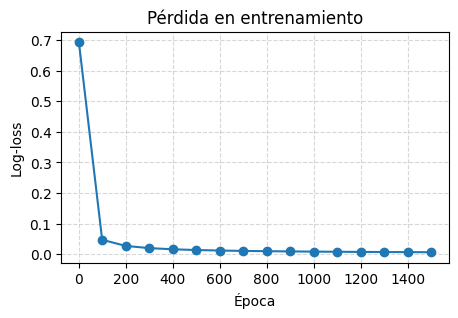

In [17]:
plt.figure(figsize=(5,3))
xs = [e for e,_ in hist]
ys = [l for _,l in hist]
plt.plot(xs, ys, marker='o')
plt.title("Pérdida en entrenamiento")
plt.xlabel("Época")
plt.ylabel("Log-loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Metricas

In [18]:
# Predicciones
yprob_te = forward(Xte, W, b)

# Umbral 0.5 por defecto
yth_te = (yprob_te >= 0.5).astype(int)

# Métricas manuales
acc = accuracy(yte, yth_te)

TP = int(np.sum((yte==1) & (yth_te==1)))
TN = int(np.sum((yte==0) & (yth_te==0)))
FP = int(np.sum((yte==0) & (yth_te==1)))
FN = int(np.sum((yte==1) & (yth_te==0)))

precision = TP / (TP + FP + 1e-9)
recall    = TP / (TP + FN + 1e-9)
f1        = 2*precision*recall / (precision + recall + 1e-9)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1       : {f1:.3f}")
print("Matriz de confusión [ [TN FP] [FN TP] ] =")
print(np.array([[TN, FP],[FN, TP]]))


Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1       : 1.000
Matriz de confusión [ [TN FP] [FN TP] ] =
[[35  0]
 [ 0 38]]


# Ejemplo

In [19]:
# 7h de sueño, 2.1L agua, 9000 pasos, 300 cal chatarra, estrés=4
nuevo = np.array([[7.0, 2.1, 9000, 300, 4.0]], dtype=float)
nuevo_z = (nuevo - X_mean) / X_std
p_salud = forward(nuevo_z, W, b)[0]
print(f"Probabilidad de 'día saludable': {p_salud:.3f}")
print("Clase predicha:", int(p_salud >= 0.5))


Probabilidad de 'día saludable': 0.993
Clase predicha: 1


# Interfaz

## Funciones

In [20]:
CSV_PATH = "habitos.csv"
CSV_COLUMNS = [ "sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres","saludable", "Fecha"]

In [ ]:
def _to_float(s: str):
    s = s.strip()
    if not s:
        return None
    s = s.replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return None

def _read_csv(path=CSV_PATH):
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return pd.DataFrame(columns=CSV_COLUMNS)

    try:
        df = pd.read_csv(path)
    except Exception:
        df = pd.read_csv(path, engine="python", on_bad_lines="skip")

    for c in CSV_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan
    df = df[CSV_COLUMNS]

    # Tipos
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    # Numéricos con tolerancia
    for c in ["sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres"]:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df["saludable"] = pd.to_numeric(df["saludable"], errors="coerce").round().fillna(0).astype(int)
    return df


def _compute_promedios(path=CSV_PATH):
    df = _read_csv(path)
    df = df.dropna(subset=["Fecha"])
    if df.empty:
        return 0.0, "NO saludable", 0.0, "NO saludable"

    hoy = date.today()

    # Últimos 5 días
    ini_5d = hoy - timedelta(days=4)
    m5 = (df["Fecha"].dt.date >= ini_5d) & (df["Fecha"].dt.date <= hoy)
    prom_5d = float(df.loc[m5, "saludable"].astype(float).mean()) if m5.any() else 0.0
    status_5d = "SALUDABLE" if prom_5d >= 0.60 else "NO saludable"

    # Últimos 3 meses
    ini_3m = hoy - relativedelta(months=3)
    m3 = (df["Fecha"] >= pd.Timestamp(ini_3m)) & (df["Fecha"] <= pd.Timestamp(hoy))
    prom_3m = float(df.loc[m3, "saludable"].astype(float).mean()) if m3.any() else 0.0
    status_3m = "SALUDABLE" if prom_3m >= 0.60 else "NO saludable"

    # Evitar NaN
    if np.isnan(prom_5d): 
        prom_5d, status_5d = 0.0, "NO saludable"
    if np.isnan(prom_3m): 
        prom_3m, status_3m = 0.0, "NO saludable"

    return prom_5d, status_5d, prom_3m, status_3m


def _append_row(row: dict, path=CSV_PATH):
    exists = os.path.exists(path)
    # Armar fila en orden
    full_row = {c: np.nan for c in CSV_COLUMNS}
    full_row.update(row)
    df_row = pd.DataFrame([full_row], columns=CSV_COLUMNS)
    df_row.to_csv(path, mode="a", index=False, header=not exists)

In [22]:
def add_day():
    # Entradas
    vals = {
        "sueño(hr)": _to_float(txt_sueño.get()),
        "agua(lt)": _to_float(txt_agua.get()),
        "pasos": _to_float(txt_pasos.get()),
        "comida_chatarra(kcal)": _to_float(txt_chatarra.get()),
        "estres": _to_float(txt_estres.get()),
    }
    faltantes = [k for k,v in vals.items() if v is None]
    if faltantes:
        messagebox.showerror(
            "Datos inválidos",
            "Revisa: " + ", ".join(faltantes) + ". Usa números (coma o punto)."
        )
        return

    # Array
    nuevo = np.array([[
        vals["sueño(hr)"],
        vals["agua(lt)"],
        vals["pasos"],
        vals["comida_chatarra(kcal)"],
        vals["estres"]
    ]], dtype=float)

    safe_std = np.where(X_std == 0, 1.0, X_std)
    nuevo_z  = (nuevo - X_mean) / safe_std

    # Predicción
    p_salud = float(forward(nuevo_z, W, b)[0])      # probabilidad
    saludable = int(p_salud >= 0.5)                 # clase 0/1

    # Guardar
    row = {
        "sueño(hr)": vals["sueño(hr)"],
        "agua(lt)": vals["agua(lt)"],
        "pasos": vals["pasos"],
        "comida_chatarra(kcal)": vals["comida_chatarra(kcal)"],
        "estres": vals["estres"],
        "saludable": saludable,
        "Fecha": date.today().isoformat(),
    }
    _append_row(row, CSV_PATH)

    # Promedio
    prom_5d, status_5d, prom_3m, status_3m = _compute_promedios(CSV_PATH)

    # Actualizar GUI
    txt_pred = "SALUDABLE" if saludable else "NO saludable"
    label_resultado.config(
        text=(
            f"Predicción: \n Hoy: {txt_pred} ({p_salud*100:.1f}%)  \n"
            f"5 días: {prom_5d*100:.1f}% → {status_5d}  \n"
            f"3 meses: {prom_3m*100:.1f}% → {status_3m}"
        )
    )


## Ventana

In [23]:
CANVAS_SIZE = 300

root = tk.Tk()
root.title("Clasificador de Hábitos Saludables")

''

## Datos de entrada

In [24]:
label_sueño = tk.Label(root, text="Sueño (hr):")
label_sueño.grid(row=1, column=1, padx=10, pady=5)
txt_sueño = tk.Entry(root)
txt_sueño.grid(row=1, column=2, padx=10, pady=5)

label_agua = tk.Label(root, text="Agua (lt):")
label_agua.grid(row=2, column=1, padx=10, pady=5)
txt_agua = tk.Entry(root)
txt_agua.grid(row=2, column=2, padx=10, pady=5)

label_pasos = tk.Label(root, text="Pasos:")
label_pasos.grid(row=3, column=1, padx=10, pady=5)
txt_pasos = tk.Entry(root)
txt_pasos.grid(row=3, column=2, padx=10, pady=5)

label_chatarra = tk.Label(root, text="Comida chatarra (kcal):")
label_chatarra.grid(row=4, column=1, padx=10, pady=5)
txt_chatarra = tk.Entry(root)
txt_chatarra.grid(row=4, column=2, padx=10, pady=5)

label_estres = tk.Label(root, text="Estrés(1-10):")
label_estres.grid(row=5, column=1, padx=10, pady=5)
txt_estres = tk.Entry(root)
txt_estres.grid(row=5, column=2, padx=10, pady=5)

label_prediccion = tk.Label(root, text="Tu día fue:")
label_prediccion.grid(row=2, column=3, padx=10, pady=5)
label_resultado = tk.Label(root, text="(esperando datos...)")
label_resultado.grid(row=3, column=3, padx=10, pady=5)

## Botones

In [25]:
btn_add = tk.Button(root, text="Agregar Día", command=add_day)
btn_add.grid(row=1, column=3, padx=10, pady=5)

## GUI

In [26]:
root.mainloop()